# 04.Evaluate Emotion Model

This notebook evaluates the trained model using the test set.

## Evaluation outputs

- Test accuracy
- Macro F1-score
- Weighted F1-score
- Classification report
- Confusion matrix
- Sample predictions

In [1]:
# Import required libraries
from pathlib import Path
import json

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\.venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Set paths

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "emotion_model_v2"

TEST_PATH = PROCESSED_DATA_DIR / "test.csv"
LABEL_MAPPING_PATH = PROCESSED_DATA_DIR / "label_mapping.json"

print("Project root:", PROJECT_ROOT)
print("Model directory:", MODEL_DIR)
print("Test file exists:", TEST_PATH.exists())
print("Model directory exists:", MODEL_DIR.exists())

Project root: c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\emotion_classifier
Model directory: c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\emotion_classifier\models\emotion_model_v2
Test file exists: True
Model directory exists: True


## 2. Load test data and mapping

In [3]:
test_df = pd.read_csv(TEST_PATH)

with open(LABEL_MAPPING_PATH, "r", encoding="utf-8") as f:
    label_mapping = json.load(f)

label2id = label_mapping["label2id"]
id2label = {int(k): v for k, v in label_mapping["id2label"].items()}
UI_LABEL_NAMES = label_mapping["ui_label_names"]

print("Test shape:", test_df.shape)
display(test_df.head())

display(test_df["label"].value_counts().reindex(UI_LABEL_NAMES).to_frame("test_count"))

Test shape: (20782, 3)


,text,label,label_id
0,[NAME]’ column the other day had an interestin...,calm,1
1,I have seen the movie Nosferatu. Believe it or...,confused,6
2,i did not and i would have voiced my oppositio...,calm,1
3,You didnt!,calm,1
4,"Well if T_D users like Coolio, maybe they ain'...",calm,1


,test_count
label,
happy,7722
calm,6049
sad,1644
angry,2953
anxious,231
stressed,86
confused,2097


## 3. Load trained model and tokenizer

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(str(MODEL_DIR))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
model.to(device)
model.eval()

print("Model loaded successfully.")

Using device: cpu


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9771.51it/s]

Model loaded successfully.


## 4. Prepare test dataset

In [5]:
MAX_LENGTH = 128

test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])
test_dataset = test_dataset.rename_column("label_id", "labels")

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

test_dataset = test_dataset.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(test_dataset)

Map: 100%|██████████| 20782/20782 [00:00<00:00, 88411.48 examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 20782
})


## 5. Run prediction

In [6]:
# Minimal TrainingArguments needed for prediction with Trainer
eval_args = TrainingArguments(
    output_dir=str(PROJECT_ROOT / "eval_outputs"),
    per_device_eval_batch_size=16,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=eval_args,
    processing_class=tokenizer,
    data_collator=data_collator
)

pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

print("Prediction complete.")

c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\.venv2\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Prediction complete.


## 6. Calculate final metrics

In [7]:
test_accuracy = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average="macro")
test_weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print("Test Accuracy:", round(test_accuracy, 4))
print("Test Macro F1:", round(test_macro_f1, 4))
print("Test Weighted F1:", round(test_weighted_f1, 4))

Test Accuracy: 0.4646
Test Macro F1: 0.3636
Test Weighted F1: 0.4813


## 7. Classification report

In [8]:
report = classification_report(
    y_true,
    y_pred,
    target_names=UI_LABEL_NAMES,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       happy     0.7791    0.5811    0.6657      7722
        calm     0.5613    0.2210    0.3172      6049
         sad     0.3823    0.4355    0.4072      1644
       angry     0.3579    0.5679    0.4391      2953
     anxious     0.1343    0.6753    0.2240       231
    stressed     0.0281    0.4419    0.0529        86
    confused     0.3488    0.5937    0.4395      2097

    accuracy                         0.4646     20782
   macro avg     0.3703    0.5023    0.3636     20782
weighted avg     0.5708    0.4646    0.4813     20782



## 8. Confusion matrix

<Figure size 800x800 with 0 Axes>

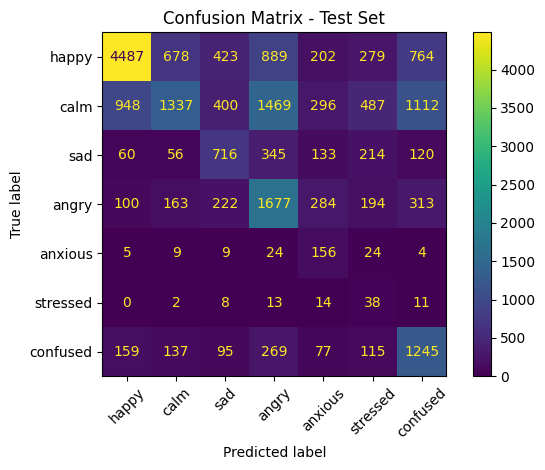

In [9]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(UI_LABEL_NAMES))))

plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=UI_LABEL_NAMES)
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()

## 9. Sample predictions

In [10]:
# Add predictions to dataframe
results_df = test_df.copy()
results_df["predicted_label_id"] = y_pred
results_df["predicted_label"] = results_df["predicted_label_id"].map(id2label)
results_df["correct"] = results_df["label"] == results_df["predicted_label"]

# Show random predictions
sample_results = results_df[["text", "label", "predicted_label", "correct"]].sample(15, random_state=42)
display(sample_results)

,text,label,predicted_label,correct
803,"Love this, and the comments are great, thanks ...",happy,happy,True
17215,Not true at all,angry,angry,True
20538,All that matters is how you use those four inc...,calm,calm,True
19601,[NAME] being the most manipulative person in t...,angry,angry,True
10246,Oh that's good!,happy,happy,True
14670,It is so crazy to me that people unironcally u...,happy,angry,False
10520,Every time you share this with someone you tea...,angry,calm,False
12939,I'd very much doubt many people believe there ...,calm,confused,False
3634,Honey is a cutie! My aunt and uncle have a dog...,happy,calm,False
14884,You are my own side. I feel an affinity for th...,happy,happy,True


## 10. Save evaluation results

In [11]:
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

metrics = {
    "test_accuracy": float(test_accuracy),
    "test_macro_f1": float(test_macro_f1),
    "test_weighted_f1": float(test_weighted_f1)
}

with open(RESULTS_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

results_df.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

print("Saved metrics to:", RESULTS_DIR / "test_metrics.json")
print("Saved predictions to:", RESULTS_DIR / "test_predictions.csv")

Saved metrics to: c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\emotion_classifier\results\test_metrics.json
Saved predictions to: c:\Users\Lenovo\Documents\GitHub\PetChat-2.0\emotion_classifier\results\test_predictions.csv


## Evaluation Summary

- Accuracy shows overall correctness.
- Macro F1 is important because it treats each emotion equally.
- Weighted F1 considers class frequency.
- The confusion matrix helps show which emotions are commonly confused.